<a href="https://colab.research.google.com/github/gre1wy/Machine_Learning/blob/main/lab3/lab3_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import os
import numpy as np
import pandas as pd
import time

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [25]:
from sklearn import tree
from numba import njit
from sklearn.ensemble import RandomForestClassifier

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

In [27]:
!pip install imblearn

In [28]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [20]:
!pip install yellowbrick

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.6/282.6 kB 7.7 MB/s eta 0:00:00


In [29]:
from yellowbrick.classifier import ClassPredictionError

# Part 1

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stellar-classification-dataset-sdss17' dataset.
Path to dataset files: /kaggle/input/stellar-classification-dataset-sdss17


In [31]:
csv_file = os.path.join(path, "star_classification.csv")
df = pd.read_csv(csv_file)

In [32]:
df.drop(['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'MJD', 'fiber_ID', 'plate'], axis=1, inplace=True)
col = df.pop("class")
df.insert(0, "class", col)
cols = ['g', 'z', 'u']
df = df[~(df[cols] == -9999).any(axis=1)]



In [33]:
df["class"]=[0 if i == "GALAXY" else 1 if i == "STAR" else 2 for i in df["class"]]

In [34]:
def rem_outliers(df, factor=1.5):
    dataset = df.copy()
    initial_rows = dataset.shape[0]

    for col in dataset.select_dtypes(include='number').columns:
        q1 = dataset[col].quantile(0.25)
        q3 = dataset[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        dataset = dataset[(dataset[col] >= lower) & (dataset[col] <= upper)]

    removed = initial_rows - dataset.shape[0]
    return dataset, removed
df_clean, deleted = rem_outliers(df)
print("Number of outliers deleted are : ", deleted)

Number of outliers deleted are :  9399


In [35]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90600 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   class     90600 non-null  int64  
 1   alpha     90600 non-null  float64
 2   delta     90600 non-null  float64
 3   u         90600 non-null  float64
 4   g         90600 non-null  float64
 5   r         90600 non-null  float64
 6   i         90600 non-null  float64
 7   z         90600 non-null  float64
 8   redshift  90600 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 6.9 MB


# Part 2

https://www.youtube.com/watch?v=_L39rN6gz7Y  
https://github.com/enesozeren/machine_learning_from_scratch/blob/main/decision_trees/decision_tree.py

In [36]:
df_clean

,class,alpha,delta,u,g,r,i,z,redshift
0,0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794
1,0,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136
2,0,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195
3,0,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346
4,0,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123
...,...,...,...,...,...,...,...,...,...
99995,0,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,0.000000
99996,0,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,0.404895
99997,0,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,0.143366
99998,0,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,0.455040


In [37]:
X = df_clean.drop('class', axis=1)
y = df_clean['class'].values

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43, stratify=y
)

# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
# )

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [39]:
sm = SMOTE(random_state=42)
print('Original dataset shape %s' % Counter(y_train))
X_train, y_train = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_train))

Original dataset shape Counter({np.int64(0): 47297, np.int64(1): 17207, np.int64(2): 7976})
Resampled dataset shape Counter({np.int64(1): 47297, np.int64(0): 47297, np.int64(2): 47297})


## Test decision tree sklearn

In [40]:
tree_sklearn = tree.DecisionTreeClassifier()
tree_sklearn = tree_sklearn.fit(X_train, y_train)

In [41]:
res = cross_val_score(tree_sklearn, X_test, y_test, cv=10)

In [42]:
print(res)
print(np.mean(res))

[0.96633554 0.95584989 0.95419426 0.95419426 0.95474614 0.9602649
 0.94701987 0.95474614 0.95198675 0.96688742]
0.9566225165562912


In [43]:
classes = ['GALAXY','STAR','QSO']

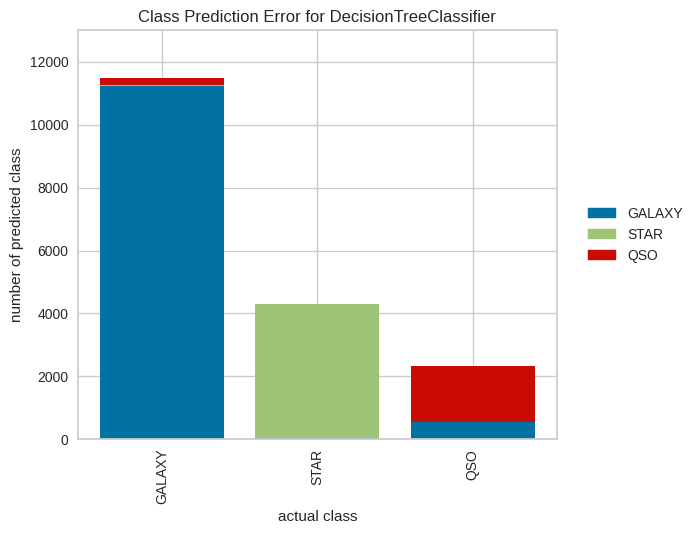

<Axes: title={'center': 'Class Prediction Error for DecisionTreeClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [44]:
visualizer = ClassPredictionError(tree_sklearn, classes=classes)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

## Decision tree from scratch

In [45]:
class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


In [46]:
@njit(fastmath=True) # x11 speed :) for forest
def best_split_numba(X, y_encoded, n_classes, parent_impurity):
    n_samples, n_features = X.shape
    best_gain = -1.0
    best_feature = -1
    best_threshold = 0.0
    total_count = len(y_encoded)
    num_total = np.bincount(y_encoded, minlength=n_classes)

    for feature in range(n_features):
        idxs = np.argsort(X[:, feature])
        X_sorted = X[idxs, feature]
        y_sorted = y_encoded[idxs]
        num_left = np.zeros(n_classes)

        for i in range(1, n_samples):
            class_gone_to_left = y_sorted[i - 1]
            num_left[class_gone_to_left] += 1

            if X_sorted[i] == X_sorted[i - 1]:
                continue

            left_count = i
            right_count = total_count - i
            num_right = num_total - num_left

            gini_left = 1.0 - np.sum((num_left / left_count) ** 2)
            gini_right = 1.0 - np.sum((num_right / right_count) ** 2)
            weighted_gini = (left_count / total_count) * gini_left + (right_count / total_count) * gini_right

            gain = parent_impurity - weighted_gini

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = (X_sorted[i - 1] + X_sorted[i]) / 2.0

    return best_feature, best_threshold, best_gain

In [47]:
class DecisionTree:
    def __init__(self, max_depth=4, min_samples_split=2, numb_of_features_splitting=None):
      self.max_depth = max_depth
      self.min_samples_split = min_samples_split
      self.root = None
      self.numb_of_features_splitting = numb_of_features_splitting

    def _gini(self, y):
      classes, counts = np.unique(y, return_counts=True)
      probs = counts / counts.sum()
      return 1 - np.sum(probs ** 2)

    def _split(self, X_column, threshold):
      left_idxs = np.where(X_column <= threshold)[0]
      right_idxs = np.where(X_column > threshold)[0]
      return left_idxs, right_idxs

    def _select_features_to_use(self, X: np.array):
        feature_idx = list(range(X.shape[1]))

        if self.numb_of_features_splitting == "sqrt":
            feature_idx_to_use = np.random.choice(feature_idx, size=int(np.sqrt(len(feature_idx))))
        elif self.numb_of_features_splitting == "log":
            feature_idx_to_use = np.random.choice(feature_idx, size=int(np.log2(len(feature_idx))))
        else:
            feature_idx_to_use = feature_idx

        return feature_idx_to_use

    def _best_split(self, X, y):
      classes, y_encoded = np.unique(y, return_inverse=True)
      parent_impurity = self._gini(y)
      feat, thresh, gain = best_split_numba(X, y_encoded, len(classes), parent_impurity)
      if gain <= 0:
          return None, None
      return feat, thresh

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth) or (n_labels == 1) or (n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return TreeNode(value=leaf_value)

        feat, thresh = self._best_split(X, y)
        # catch if gain=0
        if feat is None:
            leaf_value = self._most_common_label(y)
            return TreeNode(value=leaf_value)

        left_idxs, right_idxs = self._split(X[:, feat], thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return TreeNode(feature=feat, threshold=thresh, left=left, right=right)

    def _most_common_label(self, y):
        vals, counts = np.unique(y, return_counts=True)
        return vals[np.argmax(counts)]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

    def score(self, X, y_true):
        """For cross_val_score"""
        y_pred = self.predict(X)
        return accuracy_score(y_true, y_pred)

    def get_params(self, deep=True):
        return {
            "max_depth": self.max_depth,
            "min_samples_split": self.min_samples_split,
            "numb_of_features_splitting": self.numb_of_features_splitting
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self



### Decision tree test

In [48]:
tree_scratch= DecisionTree()
tree_scratch.fit(X_train, y_train)

In [49]:
res2 = cross_val_score(tree_scratch, X_test, y_test, cv=10)

In [50]:
print("Scores:", res2)
print("Mean accuracy:", res2.mean())

Scores: [0.96192053 0.95253863 0.96633554 0.95971302 0.96081678 0.95860927
 0.95640177 0.95419426 0.96412804 0.95860927]
Mean accuracy: 0.9593267108167769


In [51]:
predicted = tree_scratch.predict(X_test)

In [52]:
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     11824
           1       1.00      1.00      1.00      4302
           2       0.74      0.82      0.78      1994

    accuracy                           0.95     18120
   macro avg       0.90      0.92      0.91     18120
weighted avg       0.95      0.95      0.95     18120



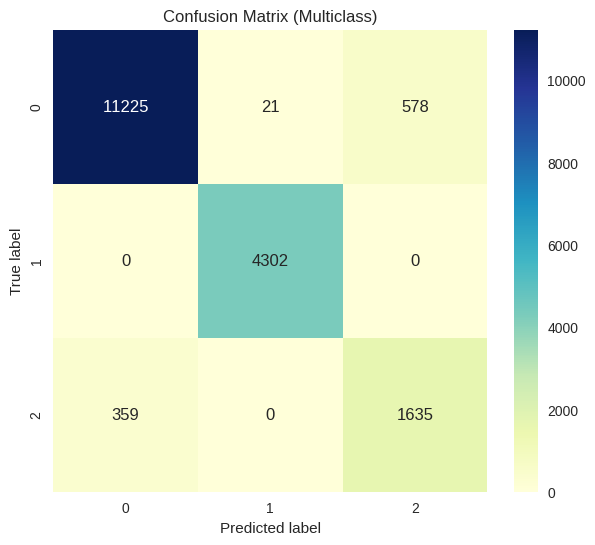

In [53]:
cm = confusion_matrix(y_test, predicted)
labels = sorted(list(set(y_test)))

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Multiclass)")
plt.show()

## Random Forest

In [54]:
class RandomForestClassifier:
    def __init__(self, n_base_learner=10, max_depth=5, min_samples_leaf=2,
                 numb_of_features_splitting=None, bootstrap_sample_size=None,
                 random_state=None):
        self.n_base_learner = n_base_learner
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.numb_of_features_splitting = numb_of_features_splitting
        self.bootstrap_sample_size = bootstrap_sample_size
        self.random_state = random_state

        if random_state is not None:
            np.random.seed(random_state)

    def fit(self, X, y):
        n_samples = X.shape[0]
        sample_size = self.bootstrap_sample_size or n_samples

        self.base_learner_list = []

        for _ in range(self.n_base_learner):
            sample_idx = np.random.choice(n_samples, size=sample_size, replace=True)
            X_s, y_s = X[sample_idx], y[sample_idx]

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_leaf,
                numb_of_features_splitting=self.numb_of_features_splitting
            )
            tree.fit(X_s, y_s)
            self.base_learner_list.append(tree)
        return self

    def predict(self, X_set: np.array) -> np.array:
        tree_preds = np.array([tree.predict(X_set) for tree in self.base_learner_list])

        tree_preds = tree_preds.T

        final_preds = np.array([
            np.bincount(sample_preds).argmax() for sample_preds in tree_preds
        ])

        return final_preds

    def score(self, X, y_true):
        y_pred = self.predict(X)
        return accuracy_score(y_true, y_pred)

    def get_params(self, deep=True):
        return {
            "n_base_learner": self.n_base_learner,
            "max_depth": self.max_depth,
            "min_samples_leaf": self.min_samples_leaf,
            "numb_of_features_splitting": self.numb_of_features_splitting,
            "bootstrap_sample_size": self.bootstrap_sample_size,
            "random_state": self.random_state,
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [56]:
forest = RandomForestClassifier(n_base_learner=100, max_depth=np.inf, numb_of_features_splitting = "sqrt", bootstrap_sample_size = int(len(y_train)/2), random_state=42)
forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.970364238410596


In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11824
           1       1.00      1.00      1.00      4302
           2       0.85      0.91      0.87      1994

    accuracy                           0.97     18120
   macro avg       0.94      0.96      0.95     18120
weighted avg       0.97      0.97      0.97     18120



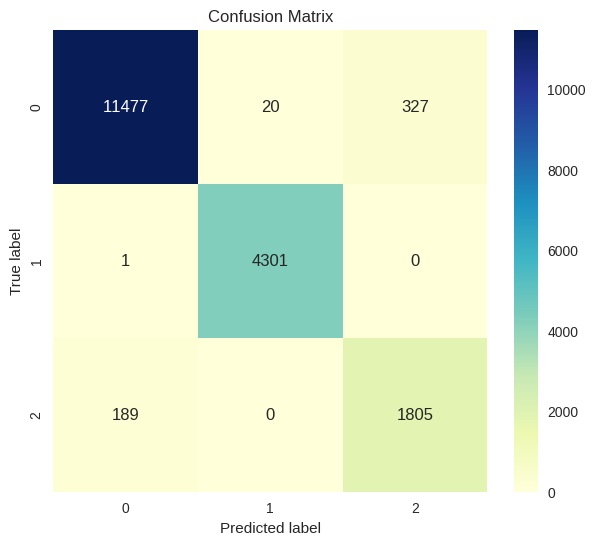

In [59]:
cm = confusion_matrix(y_test, y_pred)
labels = sorted(list(set(y_test)))

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()